# Tau Bubble Chart (All Countries)

Interactive notebook to inspect all-country sector bubbles for `tau`, `tau_dir`, `tau_amp`, or `tau_amp2`.
Markers are fixed-size, small, and transparent to reduce clutter.

In [42]:
from pathlib import Path
import os
import sys
import importlib

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(project_root)
src_path = str(project_root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from io_networks.config import load_config
import io_networks.viz as viz
importlib.reload(viz)
prepare_all_countries_bubble_data = viz.prepare_all_countries_bubble_data
plot_all_countries_dot_whisker = viz.plot_all_countries_dot_whisker
import matplotlib.pyplot as plt


In [43]:
cfg = load_config('config/default.yaml')
year = 2019
metric = 'tau_amp'  # one of: tau, tau_dir, tau_amp, tau_amp2
group_col = 'sector_abbreviation'  # use abbreviations on axis
mark_buckets = False
yscale = 'linear'  # 'linear' or 'log'
flip_axes = False
metric_clip_quantiles = (0, 1)
metric_decimals = 3
weighted = False
weight_col = 'hfce_proxy'  # sector HFCE weight
sort_by = 'median'  # 'group' or 'median'
fit_median_regression = False
dot_size = 75
whisker_linewidth = 1.75
bucket_colors = {
    'Agriculture': "#3f4348",
    'Manufacturing': "#c97a3d",
    'Services': "#8eb8e5",
}


In [44]:
df = prepare_all_countries_bubble_data(
    cfg=cfg,
    year=year,
    metric=metric,
)
print(df[['label', 'country_code', 'sector_code', metric, 'hfce_proxy']].head(10).to_string(index=False))
print(f"rows={len(df)}  countries={df['country_code'].nunique()}  year={year}  metric={metric}")


  label country_code sector_code  tau_amp  hfce_proxy
AGO_A01          AGO         A01 0.010444   4507.4846
ARE_A01          ARE         A01 0.014086   2968.8795
ARG_A01          ARG         A01 0.038153   9331.1926
AUS_A01          AUS         A01 0.021000  12992.9734
AUT_A01          AUT         A01 0.021786   3198.6759
BEL_A01          BEL         A01 0.029928   3721.7571
BGD_A01          BGD         A01 0.010434  14400.6726
BGR_A01          BGR         A01 0.035046   1839.8939
BLR_A01          BLR         A01 0.033718   2280.2179
BRA_A01          BRA         A01 0.036736  41527.3398
rows=3888  countries=81  year=2019  metric=tau_amp


In [45]:
df = df[df["sector_abbreviation"] != "HOU"].copy()

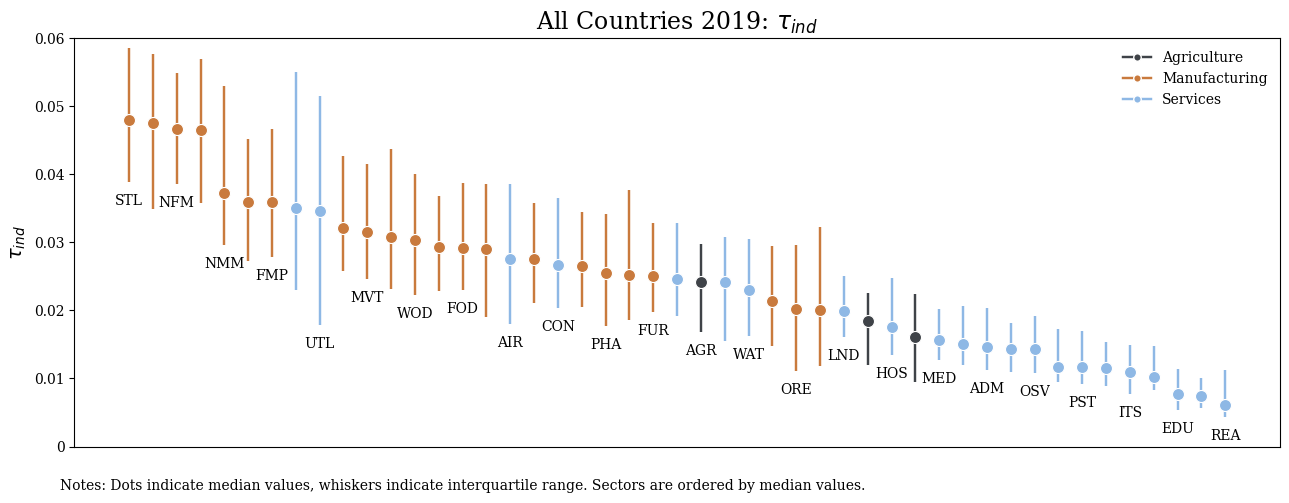

In [47]:
metric_labels = {
    'tau': r'$\tau$',
    'tau_dir': r'$\tau_{dir}$',
    'tau_amp': r'$\tau_{ind}$',
    'tau_amp2': r'$\tau$ with $\tau_{amp}$ tails',
}
metric_label = metric_labels.get(metric, metric)
weight_note = 'weighted by HFCE proxy' if weighted else 'unweighted'
sort_note = 'sorted by weighted median' if (weighted and sort_by == 'median') else (
    'sorted by median' if sort_by == 'median' else 'group order'
)
title = f'All Countries {year}: {metric_label}'

fig, ax = plt.subplots(figsize=(13, 5))
ax = plot_all_countries_dot_whisker(
    df,
    metric=metric,
    group_col=group_col,
    mark_buckets=mark_buckets,
    yscale=yscale,
    flip_axes=flip_axes,
    metric_clip_quantiles=metric_clip_quantiles,
    metric_decimals=metric_decimals,
    weighted=weighted,
    weight_col=weight_col,
    sort_by=sort_by,
    fit_median_regression=fit_median_regression,
    report_r2=False,
    title=title,
    dot_size=dot_size,
    whisker_linewidth=whisker_linewidth,
    bucket_colors=bucket_colors,
    ax=ax,
)

stats_df = getattr(ax, '_dot_whisker_stats', None)
ax.set_xticklabels([])
ax.tick_params(axis='x', length=0)
if stats_df is not None:
    ymin, ymax = ax.get_ylim()
    label_offset = 0.01 * (ymax - ymin)
    for i, row in enumerate(stats_df.itertuples(index=False)):
        if i % 2 != 0:
            continue
        ax.text(
            row.position,
            row.q25 - label_offset,
            row.label,
            ha='center',
            va='top',
            fontsize=10,
            fontfamily='serif',
            clip_on=False,
        )

fig.text(
    0.05, 0.01,
    'Notes: Dots indicate median values, whiskers indicate interquartile range. Sectors are ordered by median values.',
    ha='left',
    fontsize=10,
    color='black',
    fontfamily='serif',
)
ax.set_ylim(0, 0.06)
ax.set_ylabel(r"$\tau_{ind}$", fontfamily='serif', fontsize=14)

fig.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('all_countries_tau_2019.pdf', bbox_inches='tight', dpi=300)
plt.show()

## Try Different Inputs

- Change `year` (1995-2022)
- Change `metric` (`tau`, `tau_dir`, `tau_amp`, `tau_amp2`)
- Toggle `show_points` and tune `point_alpha` / `point_size` for clutter control
